# TP3 — Clasificación, Clustering y Ensamble
### Inteligencia Artificial y Aprendizaje Automático I · 2026
### Dataset: transacciones inmobiliarias — Prefectura de Tokio (MLIT)

Tercera etapa del proyecto integrador. Partimos del dataset limpio del TP1
(`tokyo_tp1_procesado.csv`, toda la Prefectura de Tokio) y retomamos la pregunta de clasificación:

> **¿Podemos predecir la estructura del edificio (W / S / RC / SRC) a partir de las características del
> lote, su ubicación y su entorno urbano?**

Usamos como target `estructura_principal`, la versión **normalizada** que derivó el TP1: la columna
original `Building : Structure` es multi-etiqueta (`"RC, W"`) y tiene ~25 categorías, así que se redujo
al sistema constructivo principal agrupando las clases raras (`LS`, `B`) en `"Otros"`.

Comparamos **≥3 clasificadores** (baseline + dos ensambles) con marco controlado (hold-out 80/20
estratificado + StratifiedKFold), métricas adecuadas al **desbalance severo**, matrices de confusión, y
dos extensiones valoradas: **clustering** (K-Means + PCA) y comparación de **ensambles** contra el
baseline.

## 0. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, label_binarize
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import MiniBatchKMeans
from sklearn.decomposition import PCA
from sklearn.metrics import (accuracy_score, precision_recall_fscore_support, f1_score,
                             classification_report, confusion_matrix, cohen_kappa_score,
                             roc_auc_score, adjusted_rand_score)

try:
    from xgboost import XGBClassifier
    HAY_XGB = True
except ImportError:
    from sklearn.ensemble import GradientBoostingClassifier
    HAY_XGB = False
    print("XGBoost no disponible: se usará GradientBoostingClassifier como tercer modelo.")

# --- Detección de GPU (NVIDIA) para XGBoost -------------------------------------------------
# XGBoost puede entrenar en GPU con device="cuda". Random Forest y Logística de scikit-learn
# son CPU-only, por eso se controlan vía hiperparámetros.
USAR_GPU = False
if HAY_XGB:
    try:
        import subprocess
        subprocess.run(["nvidia-smi"], capture_output=True, check=True, timeout=10)
        USAR_GPU = True
        print("GPU NVIDIA detectada: XGBoost entrenará en GPU (device='cuda').")
    except Exception:
        print("Sin GPU NVIDIA disponible: XGBoost entrenará en CPU.")

sns.set_theme(style="whitegrid", palette="deep")
pd.set_option("display.max_columns", 40)
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

DATA_PATH = "outputs/processed/tokyo_tp1_procesado.csv"   # salida del TP1
MODEL_DIR = "outputs/models"
os.makedirs(MODEL_DIR, exist_ok=True)

GPU NVIDIA detectada: XGBoost entrenará en GPU (device='cuda').


## A. Marco experimental

### A.1 Problema
Clasificación **multiclase** de `estructura_principal`: **W** (madera), **S** (acero), **RC** (hormigón
armado), **SRC** (acero-hormigón) y **Otros** (clases marginales `LS`/`B`). Solo tiene sentido en
operaciones **con edificio**: las filas *Land Only* no tienen estructura y se excluyen.

### A.2 Desbalance — severo
El EDA del TP1 mostró que **`W` (madera) es abrumadoramente mayoritaria** (~180k casos) frente a `S` y
`RC` (~20k cada una), con `SRC` y `Otros` casi testimoniales. **Decisiones:**
- `stratify` en el split y `StratifiedKFold` en la CV para preservar la proporción de clases.
- **`class_weight="balanced"`** en los modelos que lo soportan (penaliza más el error en las clases raras).
  SMOTE queda como alternativa opcional (sección 7.1), para no depender de `imbalanced-learn`.
- Métrica prioritaria: **F1 macro**. Con este desbalance, un modelo que prediga siempre `W` alcanzaría
  una accuracy altísima siendo inútil: la accuracy es directamente engañosa acá.

### A.3 Features
Se reutilizan las mismas del TP1/TP2 (superficie, frente, `distancia_estacion_min`, antigüedad, ratios
urbanísticos, zona, forma, orientación/tipo de calle, `ward`, district/estación agrupados).
**Exclusiones:** `precio_suelo_m2` (solo Land Only) y la columna cruda `Building : Structure` (de la que
deriva el target). `Total transaction value` y `precio_por_m2` **sí pueden usarse** como predictores acá,
porque el target no es el precio.

### A.4 Los 3 clasificadores
| Modelo | Rol | Por qué acá |
|---|---|---|
| **Regresión Logística** (multinomial) | Baseline | Lineal interpretable; fija el piso de rendimiento. |
| **Random Forest** | Ensamble | Maneja bien multiclase desbalanceada; da importancia de variables. |
| **XGBoost** | Boosting | Suele lograr el mejor F1 en multiclase tabular; robusto al desbalance. |

## 1. Carga del dataset procesado del TP1

In [2]:
df = pd.read_csv(DATA_PATH)
print("Shape del dataset completo:", df.shape)
df.head(3)

Shape del dataset completo: (343995, 42)


,ward,District,district_agrupado,Nearest station : Name,estacion_agrupada,Type,Area,City planning,Land : Shape,Frontage road : Direction,Frontage road : Type,anio_operacion,trimestre_operacion,anio_construccion,antiguedad,antes_de_guerra,antiguedad_inconsistente,area_terreno_m2,area_terreno_capada,area_construida_m2,...,ratio_construido_sospechoso,Frontage,Frontage road : Width,Building coverage ratio,Floor area ratio,distancia_estacion_min,distancia_estacion_nula,uso_house,uso_office,uso_shop,uso_warehouse,uso_parking_lot,uso_housing_complex,sin_edificio,tiene_nota_transaccion,precio_suelo_m2,precio_por_m2,Total transaction value,Building : Structure,estructura_principal
0,Chiyoda,Iidabashi,Otros,Iidabashi,Otros,Residential Land(Land and Building),Commercial Area,Commerical,Rectangular Shaped,Northeast,Tokyo Metropolitan Road,2025,2,1954.0,71.0,0,0,50,False,75.0,...,0,3.5,27.0,80.0,700.0,0.0,0,1,0,1,0,0,0,0,0,NaN,6.800000e+06,340000000,W,W
1,Chiyoda,Iidabashi,Otros,Iidabashi,Otros,Residential Land(Land and Building),Commercial Area,Commerical,Irregular Shaped,Northwest,Ward Road,2024,3,2024.0,0.0,0,0,55,False,400.0,...,0,10.0,8.0,80.0,700.0,4.0,0,0,1,1,0,0,0,0,0,NaN,1.509091e+07,830000000,S,S
2,Chiyoda,Iidabashi,Otros,Iidabashi,Otros,Residential Land(Land and Building),Commercial Area,Commerical,Rectangular Shaped,South,Ward Road,2023,4,1970.0,53.0,0,0,95,False,320.0,...,0,7.5,10.6,80.0,500.0,1.0,0,1,1,0,1,0,0,0,0,NaN,1.894737e+06,180000000,RC,RC


## 2. Filtrado a operaciones con edificio y definición del target
La estructura solo existe cuando hay construcción. Nos quedamos con las filas que tienen
`estructura_principal` no nula (equivalente a `Type == Land and Building`).

In [3]:
TARGET = "estructura_principal"   # target normalizado por el TP1 (la columna cruda es multi-etiqueta)

# Solo filas con estructura reportada (las Land Only no tienen edificio).
df_clf = df[df[TARGET].notna()].copy().reset_index(drop=True)
print("Filas con edificio (usables para clasificar):", df_clf.shape[0])

# Distribución de clases: clave para dimensionar el desbalance.
dist = df_clf[TARGET].value_counts()
print("\nDistribución de clases:")
print(dist)
print("\nProporción (%):")
print((df_clf[TARGET].value_counts(normalize=True) * 100).round(2))

# Ratio de desbalance: cuántas veces la clase mayoritaria supera a la minoritaria.
print(f"\nRatio mayoritaria/minoritaria: {dist.max() / dist.min():.1f}x")

Filas con edificio (usables para clasificar): 224622

Distribución de clases:
estructura_principal
W        181477
S         16845
RC        16736
Otros      6797
SRC        2767
Name: count, dtype: int64

Proporción (%):
estructura_principal
W        80.79
S         7.50
RC        7.45
Otros     3.03
SRC       1.23
Name: proportion, dtype: float64

Ratio mayoritaria/minoritaria: 65.6x


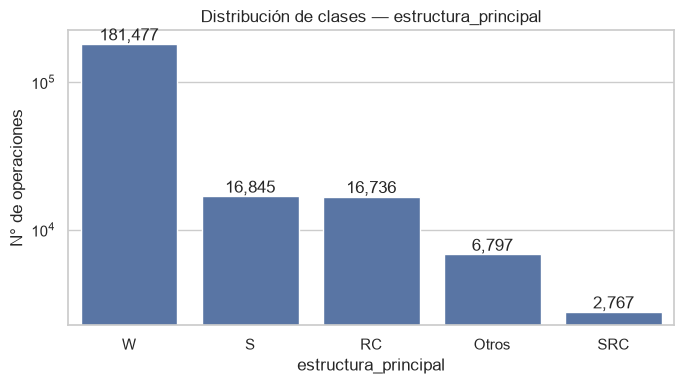

In [4]:
fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(x=dist.index, y=dist.values, ax=ax, color="#4C72B0")
ax.set_title("Distribución de clases — estructura_principal")
ax.set_ylabel("N° de operaciones")
ax.set_yscale("log")   # escala log: el desbalance es tan fuerte que en lineal las clases raras no se ven
for i, v in enumerate(dist.values):
    ax.text(i, v, f"{v:,}", ha="center", va="bottom")
plt.tight_layout()
plt.show()

## 3. Definición de `X`, `y` y grupos de columnas
Excluimos `precio_suelo_m2` (solo aplica a Land Only, todo nulo acá) y las columnas geográficas crudas
de alta cardinalidad (se usan sus versiones agrupadas). El **precio de la operación sí se incluye** como
predictor de la estructura.

In [5]:
# Excluidas: target + la columna cruda de la que deriva + columnas sin sentido en este subconjunto.
EXCLUIDAS = [TARGET, "Building : Structure", "precio_suelo_m2",
             "District", "Nearest station : Name"]

y = df_clf[TARGET].values
X = df_clf.drop(columns=[c for c in EXCLUIDAS if c in df_clf.columns]).copy()

# Flags booleanos a int por prolijidad.
for c in X.select_dtypes(include="bool").columns:
    X[c] = X[c].astype(int)

# Grupos de columnas. 'ward' entra como categórica (One-Hot dentro del pipeline) si existe.
cols_categoricas = [c for c in ["ward", "district_agrupado", "estacion_agrupada", "Type", "Area",
                                "City planning", "Land : Shape", "Frontage road : Direction",
                                "Frontage road : Type"] if c in X.columns]
cols_numericas = [c for c in X.columns if c not in cols_categoricas]

print(f"Total features: {X.shape[1]}  |  numéricas: {len(cols_numericas)}  |  categóricas: {len(cols_categoricas)}")
print("\nClases:", sorted(pd.unique(y)))

Total features: 37  |  numéricas: 28  |  categóricas: 9

Clases: ['Otros', 'RC', 'S', 'SRC', 'W']


## 4. Partición train/test estratificada
Hold-out 80/20 con `stratify=y` para que cada clase mantenga su proporción en train y test — crítico con
`W` minoritaria.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=RANDOM_STATE, stratify=y)

print("Train:", X_train.shape, " Test:", X_test.shape)
print("\nProporción de clases en train:")
print(pd.Series(y_train).value_counts(normalize=True).round(3))

Train: (179697, 37)  Test: (44925, 37)

Proporción de clases en train:
W        0.808
S        0.075
RC       0.075
Otros    0.030
SRC      0.012
Name: proportion, dtype: float64


## 5. Preprocesamiento (ColumnTransformer)
- **Numéricas:** imputación por mediana + `StandardScaler` (necesario para la Logística; indiferente
  para los árboles, se deja en el pipeline común).
- **Categóricas:** imputación por moda + `OneHotEncoder` (viable porque el TP1 ya agrupó las raras).

In [7]:
preproc_numerico = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

preproc_categorico = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocesador = ColumnTransformer([
    ("num", preproc_numerico, cols_numericas),
    ("cat", preproc_categorico, cols_categoricas),
])

## 6. Definición de los tres clasificadores
Todos con `class_weight="balanced"` donde aplica, para compensar el desbalance sin resamplear.

In [8]:
if HAY_XGB:
    # XGBoost no tiene class_weight directo en multiclase; el desbalance se maneja por métricas macro
    # y (opcionalmente) sample_weight. tree_method="hist" + GPU aceleran mucho con 200k+ filas.
    tercer_modelo = XGBClassifier(
        n_estimators=300, learning_rate=0.05, max_depth=6,
        subsample=0.8, colsample_bytree=0.8,
        objective="multi:softprob", eval_metric="mlogloss",
        tree_method="hist",
        device="cuda" if USAR_GPU else "cpu",
        random_state=RANDOM_STATE, n_jobs=-1)
    nombre_tercero = "XGBoost"
else:
    tercer_modelo = GradientBoostingClassifier(
        n_estimators=200, learning_rate=0.05, max_depth=3, random_state=RANDOM_STATE)
    nombre_tercero = "GradientBoosting"

modelos = {
    # saga + max_iter acotado: con 200k filas el solver por defecto es lento en multiclase.
    "Regresión Logística": LogisticRegression(
        max_iter=500, class_weight="balanced", n_jobs=-1, random_state=RANDOM_STATE),
    # Random Forest ACOTADO (scikit-learn es CPU-only): limitar profundidad y hojas es
    # lo que hace viable el entrenamiento con este volumen de datos.
    "Random Forest": RandomForestClassifier(
        n_estimators=200, max_depth=20, min_samples_leaf=5, max_features="sqrt",
        class_weight="balanced", random_state=RANDOM_STATE, n_jobs=-1),
    nombre_tercero: tercer_modelo,
}
print("Modelos a entrenar:", list(modelos.keys()))

Modelos a entrenar: ['Regresión Logística', 'Random Forest', 'XGBoost']


XGBoost requiere el target como enteros `0..n-1`. Creamos un mapeo consistente clase↔entero y lo
aplicamos solo cuando el modelo lo necesita (Logística y RF trabajan con las etiquetas de texto).

In [9]:
clases = sorted(pd.unique(y))
clase_a_int = {c: i for i, c in enumerate(clases)}
int_a_clase = {i: c for c, i in clase_a_int.items()}

y_train_int = np.array([clase_a_int[v] for v in y_train])
y_test_int = np.array([clase_a_int[v] for v in y_test])
print("Mapeo de clases:", clase_a_int)

Mapeo de clases: {'Otros': 0, 'RC': 1, 'S': 2, 'SRC': 3, 'W': 4}


## 7. Entrenamiento, validación cruzada y evaluación
Por modelo: `Pipeline` (preproc + modelo) → **StratifiedKFold 5** sobre train (métrica **F1 macro**) →
fit en train → predicción en train y test. Guardamos también las probabilidades para el ROC-AUC.

In [10]:
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)

def metricas_clf(y_true, y_pred):
    """Accuracy + precision/recall/F1 (macro y ponderado) + Kappa."""
    acc = accuracy_score(y_true, y_pred)
    p_macro, r_macro, f1_macro, _ = precision_recall_fscore_support(y_true, y_pred, average="macro", zero_division=0)
    _, _, f1_weighted, _ = precision_recall_fscore_support(y_true, y_pred, average="weighted", zero_division=0)
    kappa = cohen_kappa_score(y_true, y_pred)
    return {"Accuracy": acc, "Precision_macro": p_macro, "Recall_macro": r_macro,
            "F1_macro": f1_macro, "F1_weighted": f1_weighted, "Kappa": kappa}

resultados = []
pipelines_entrenados = {}
predicciones_test = {}
proba_test = {}

for nombre, modelo in modelos.items():
    pipe = Pipeline([("prep", preprocesador), ("model", modelo)])
    usa_int = nombre in ("XGBoost", "GradientBoosting")
    ytr = y_train_int if usa_int else y_train

    # CV sobre train (F1 macro)
    # n_jobs=1 A PROPÓSITO: los modelos ya paralelizan internamente (n_jobs=-1).
    # Paralelizar en ambos niveles genera sobresuscripción de threads y satura la máquina.
    cv_f1 = cross_val_score(pipe, X_train, ytr, cv=skf, scoring="f1_macro", n_jobs=1)

    # Entrenamiento final
    pipe.fit(X_train, ytr)
    pipelines_entrenados[nombre] = pipe

    # Predicciones (llevar todo a etiquetas de texto para comparar homogéneo)
    pred_train_raw = pipe.predict(X_train)
    pred_test_raw = pipe.predict(X_test)
    pred_train = np.array([int_a_clase[v] for v in pred_train_raw]) if usa_int else pred_train_raw
    pred_test = np.array([int_a_clase[v] for v in pred_test_raw]) if usa_int else pred_test_raw
    predicciones_test[nombre] = pred_test
    proba_test[nombre] = pipe.predict_proba(X_test)

    m_train = metricas_clf(y_train, pred_train)
    m_test = metricas_clf(y_test, pred_test)

    resultados.append({
        "Modelo": nombre,
        "CV_F1macro": cv_f1.mean(), "CV_F1macro_std": cv_f1.std(),
        "Acc_train": m_train["Accuracy"], "Acc_test": m_test["Accuracy"],
        "F1macro_train": m_train["F1_macro"], "F1macro_test": m_test["F1_macro"],
        "F1weighted_test": m_test["F1_weighted"], "Kappa_test": m_test["Kappa"],
    })
    print(f"{nombre:22s}  CV F1macro={cv_f1.mean():.3f}±{cv_f1.std():.3f}  "
          f"F1macro(test)={m_test['F1_macro']:.3f}  Acc(test)={m_test['Accuracy']:.3f}")

df_resultados = pd.DataFrame(resultados)

Regresión Logística     CV F1macro=0.492±0.002  F1macro(test)=0.493  Acc(test)=0.725
Random Forest           CV F1macro=0.552±0.003  F1macro(test)=0.554  Acc(test)=0.772
XGBoost                 CV F1macro=0.570±0.004  F1macro(test)=0.566  Acc(test)=0.892


### 7.1 Alternativa opcional — SMOTE
Como alternativa a `class_weight`, se puede **sobremuestrear** la clase minoritaria con SMOTE. Requiere
`imbalanced-learn` (`pip install imbalanced-learn`). Se deja como celda opcional; la estrategia principal
del TP es `class_weight`.

In [11]:
# --- OPCIONAL: descomentar si se instala imbalanced-learn ---
# from imblearn.pipeline import Pipeline as ImbPipeline
# from imblearn.over_sampling import SMOTE
#
# pipe_smote = ImbPipeline([
#     ("prep", preprocesador),
#     ("smote", SMOTE(random_state=RANDOM_STATE)),
#     ("model", RandomForestClassifier(n_estimators=300, random_state=RANDOM_STATE, n_jobs=-1)),
# ])
# pipe_smote.fit(X_train, y_train)
# pred_smote = pipe_smote.predict(X_test)
# print("F1 macro (RF + SMOTE):", f1_score(y_test, pred_smote, average="macro"))
print("Celda opcional: SMOTE no ejecutado (estrategia principal = class_weight).")

Celda opcional: SMOTE no ejecutado (estrategia principal = class_weight).


## 8. Tabla comparativa consolidada
Métricas en **train** y **test**. La columna guía es **F1 macro** (por el desbalance); accuracy se
muestra pero con la advertencia de que engaña cuando una clase domina.

In [12]:
tabla_fmt = df_resultados.copy()
for c in tabla_fmt.columns:
    if c != "Modelo":
        tabla_fmt[c] = tabla_fmt[c].round(3)
tabla_fmt.set_index("Modelo")

,CV_F1macro,CV_F1macro_std,Acc_train,Acc_test,F1macro_train,F1macro_test,F1weighted_test,Kappa_test
Modelo,,,,,,,,
Regresión Logística,0.492,0.002,0.730,0.725,0.503,0.493,0.778,0.409
Random Forest,0.552,0.003,0.803,0.772,0.649,0.554,0.812,0.485
XGBoost,0.570,0.004,0.905,0.892,0.627,0.566,0.876,0.635


## 9. Visualizaciones comparativas

### 9.1 F1 macro por modelo (barras)

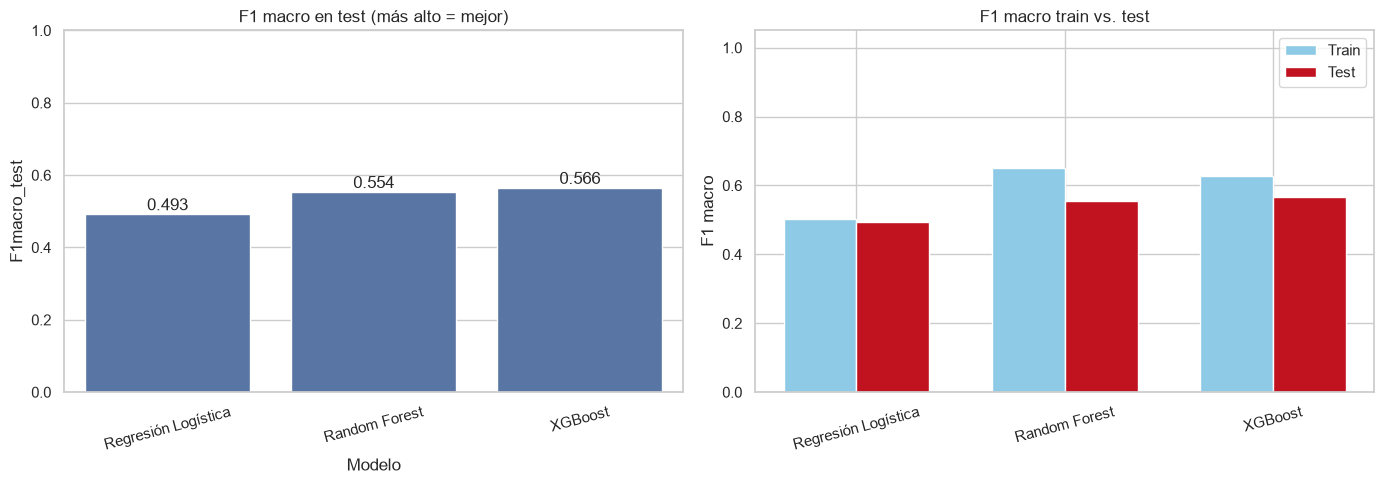

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.barplot(data=df_resultados, x="Modelo", y="F1macro_test", ax=axes[0], color="#4C72B0")
axes[0].set_title("F1 macro en test (más alto = mejor)")
axes[0].set_ylim(0, 1)
for i, v in enumerate(df_resultados["F1macro_test"]):
    axes[0].text(i, v + 0.01, f"{v:.3f}", ha="center")

# F1 macro train vs test (diagnóstico de overfitting)
x = np.arange(len(df_resultados)); ancho = 0.35
axes[1].bar(x - ancho/2, df_resultados["F1macro_train"], ancho, label="Train", color="#8ecae6")
axes[1].bar(x + ancho/2, df_resultados["F1macro_test"], ancho, label="Test", color="#c1121f")
axes[1].set_xticks(x); axes[1].set_xticklabels(df_resultados["Modelo"], rotation=15)
axes[1].set_ylabel("F1 macro"); axes[1].set_title("F1 macro train vs. test")
axes[1].legend(); axes[1].set_ylim(0, 1.05)

for ax in axes[:1]:
    ax.tick_params(axis="x", rotation=15)
plt.tight_layout()
plt.show()

### 9.2 Matrices de confusión (heatmap por modelo)
Normalizadas **por fila** (cada celda = proporción de la clase real): con un desbalance de este tamaño,
la matriz en conteos crudos sólo dejaría ver `W`. La diagonal es el recall por clase.
La confusión esperada es **RC ↔ SRC** (hormigón vs. acero-hormigón, estructuras similares).

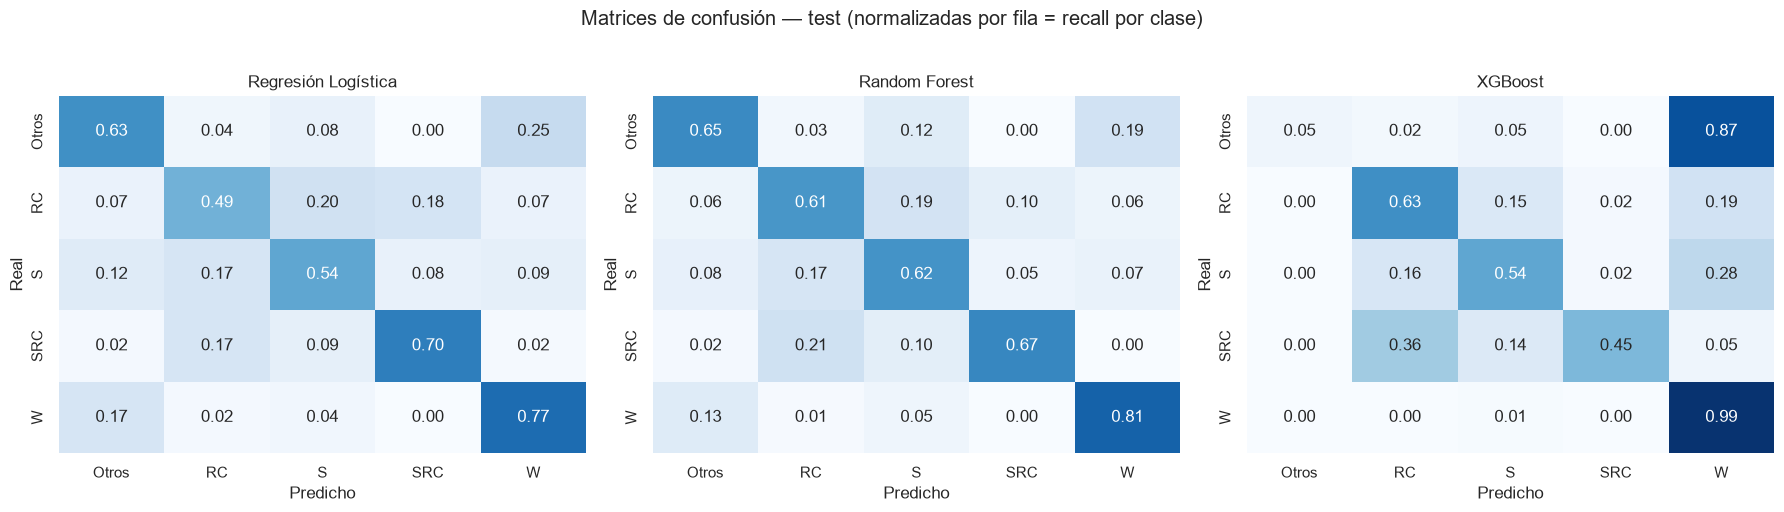

In [14]:
fig, axes = plt.subplots(1, len(modelos), figsize=(6 * len(modelos), 5))
if len(modelos) == 1:
    axes = [axes]

for ax, (nombre, pred) in zip(axes, predicciones_test.items()):
    # Normalizamos por fila (recall por clase): con el desbalance, los conteos crudos sólo muestran W.
    cm = confusion_matrix(y_test, pred, labels=clases, normalize="true")
    sns.heatmap(cm, annot=True, fmt=".2f", cmap="Blues", ax=ax, vmin=0, vmax=1,
                xticklabels=clases, yticklabels=clases, cbar=False)
    ax.set_xlabel("Predicho"); ax.set_ylabel("Real")
    ax.set_title(f"{nombre}")

plt.suptitle("Matrices de confusión — test (normalizadas por fila = recall por clase)", y=1.02)
plt.tight_layout()
plt.show()

### 9.3 Reporte por clase del mejor modelo
Precision / recall / F1 por clase (`classification_report`), para ver en qué clase concreta falla cada
modelo — sobre todo en la minoritaria.

In [15]:
mejor_nombre = df_resultados.sort_values("F1macro_test", ascending=False).iloc[0]["Modelo"]
print("Mejor modelo por F1 macro en test:", mejor_nombre, "\n")
print(classification_report(y_test, predicciones_test[mejor_nombre], digits=3, zero_division=0))

Mejor modelo por F1 macro en test: XGBoost 

              precision    recall  f1-score   support

       Otros      0.565     0.048     0.088      1360
          RC      0.701     0.633     0.666      3347
           S      0.652     0.538     0.590      3369
         SRC      0.634     0.454     0.529       553
           W      0.928     0.987     0.956     36296

    accuracy                          0.892     44925
   macro avg      0.696     0.532     0.566     44925
weighted avg      0.876     0.892     0.876     44925



## 10. ROC-AUC (one-vs-rest)
En multiclase reportamos el AUC promedio one-vs-rest (macro), que resume la capacidad de separar cada
clase del resto usando las probabilidades predichas.

In [16]:
y_test_bin = label_binarize(y_test, classes=clases)

print("ROC-AUC one-vs-rest (macro):")
for nombre, proba in proba_test.items():
    try:
        auc = roc_auc_score(y_test_bin, proba, average="macro", multi_class="ovr")
        print(f"  {nombre:22s}: {auc:.3f}")
    except ValueError as e:
        print(f"  {nombre:22s}: no calculable ({e})")

ROC-AUC one-vs-rest (macro):
  Regresión Logística   : 0.903
  Random Forest         : 0.932
  XGBoost               : 0.948


## 11. Extensiones valoradas

### 11.1 Importancia de variables (mejor modelo basado en árbol)
Si el mejor es Random Forest o XGBoost, extraemos `feature_importances_`, reconstruyendo los nombres tras
el One-Hot.

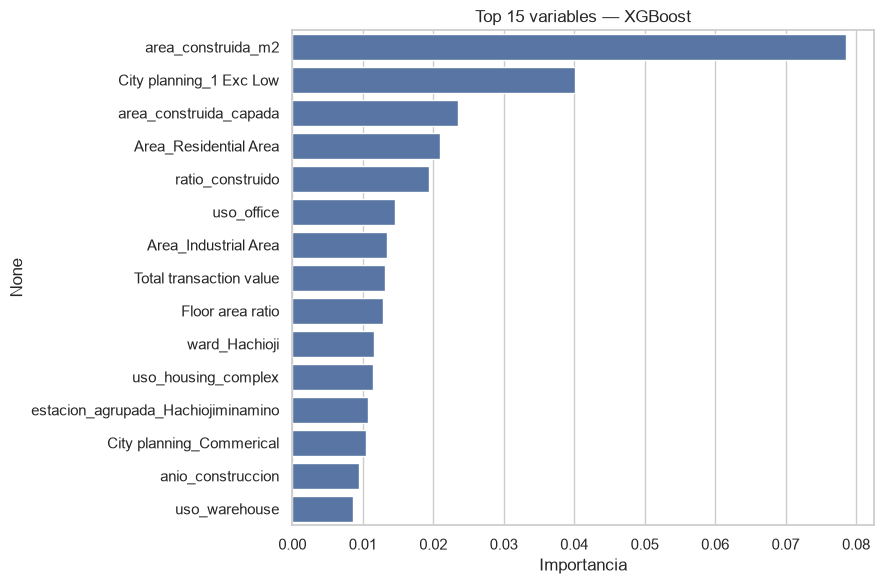

,importancia
area_construida_m2,0.078611
City planning_1 Exc Low,0.040046
area_construida_capada,0.023526
Area_Residential Area,0.020940
ratio_construido,0.019342
uso_office,0.014546
Area_Industrial Area,0.013417
Total transaction value,0.013173
Floor area ratio,0.012911
ward_Hachioji,0.011622


In [17]:
def nombres_features(pipe):
    prep = pipe.named_steps["prep"]
    nombres = list(cols_numericas)
    ohe = prep.named_transformers_["cat"].named_steps["onehot"]
    nombres += list(ohe.get_feature_names_out(cols_categoricas))
    return nombres

modelo_final = pipelines_entrenados[mejor_nombre].named_steps["model"]
if hasattr(modelo_final, "feature_importances_"):
    nombres = nombres_features(pipelines_entrenados[mejor_nombre])
    imp = pd.Series(modelo_final.feature_importances_, index=nombres).sort_values(ascending=False)
    top = imp.head(15)
    plt.figure(figsize=(9, 6))
    sns.barplot(x=top.values, y=top.index, color="#4C72B0")
    plt.title(f"Top 15 variables — {mejor_nombre}")
    plt.xlabel("Importancia")
    plt.tight_layout()
    plt.show()
    display(top.to_frame("importancia"))
else:
    print("El mejor modelo es lineal; se omiten feature_importances_.")

### 11.2 Ajuste de hiperparámetros (GridSearchCV sobre Random Forest)
Búsqueda acotada optimizando **F1 macro** en CV 3-fold estratificada.

In [18]:
from sklearn.model_selection import RandomizedSearchCV

# NOTA DE COSTO: un GridSearchCV completo sobre este volumen es inviable en escritorio.
# Usamos RandomizedSearchCV con pocas combinaciones y profundidades ya acotadas.
pipe_rf = Pipeline([("prep", preprocesador),
                    ("model", RandomForestClassifier(class_weight="balanced",
                                                     random_state=RANDOM_STATE, n_jobs=-1))])

espacio = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [12, 20, 30],
    "model__min_samples_leaf": [5, 10, 20],
}

grid = RandomizedSearchCV(pipe_rf, espacio, n_iter=5,
                          cv=StratifiedKFold(3, shuffle=True, random_state=RANDOM_STATE),
                          scoring="f1_macro", n_jobs=1, random_state=RANDOM_STATE)
grid.fit(X_train, y_train)

print("Mejores hiperparámetros:", grid.best_params_)
print(f"Mejor F1 macro en CV: {grid.best_score_:.3f}")
pred_grid = grid.predict(X_test)
print(f"F1 macro test (RF tuneado): {f1_score(y_test, pred_grid, average='macro'):.3f}")

Mejores hiperparámetros: {'model__n_estimators': 100, 'model__min_samples_leaf': 10, 'model__max_depth': 20}
Mejor F1 macro en CV: 0.533
F1 macro test (RF tuneado): 0.541


### 11.3 Clustering (K-Means + PCA) vs. clases reales
Pregunta del PDF: ¿la ubicación + tamaño + antigüedad agrupa los inmuebles **igual que su estructura**?
Corremos K-Means con `k = nº de clases` sobre las features preprocesadas (incluye `ward`), reducimos con
PCA a 2D para visualizar, y medimos la coincidencia clusters↔clases con el **Adjusted Rand Index**.

Adjusted Rand Index (clusters vs. estructura real): 0.211


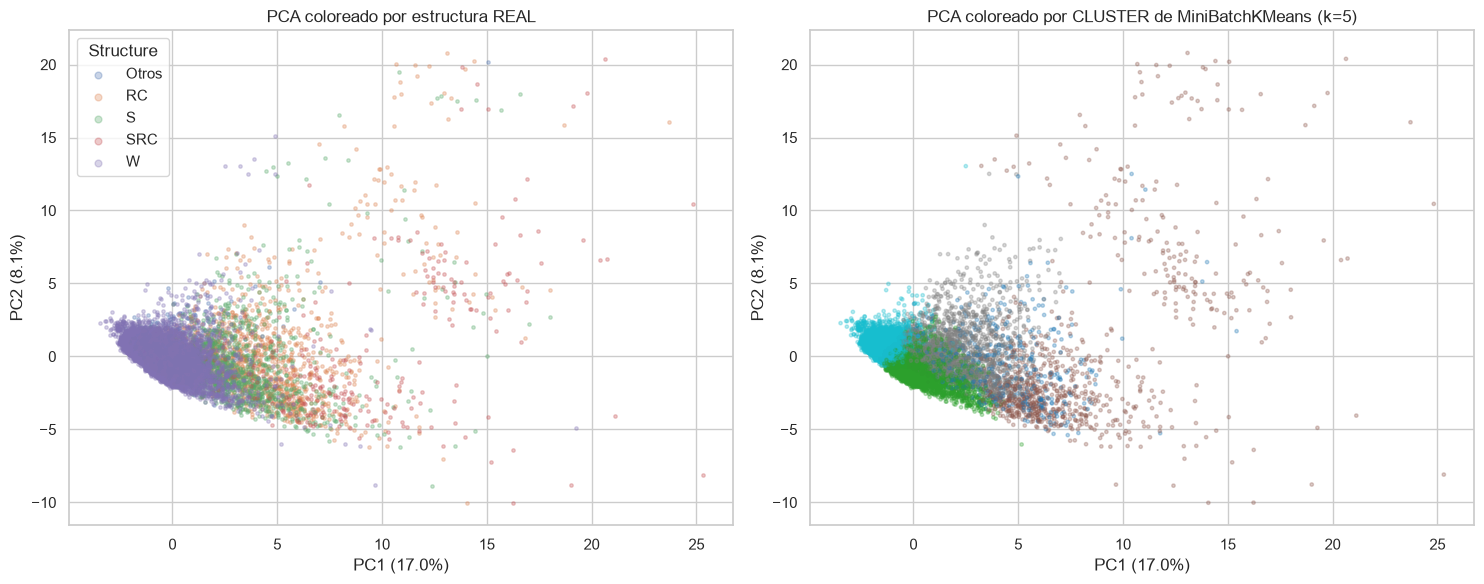

In [19]:
# Matriz de features preprocesada (misma que ven los modelos), sobre TODO el subconjunto con edificio.
X_prep = preprocesador.fit_transform(X)
X_prep = X_prep.toarray() if hasattr(X_prep, "toarray") else np.asarray(X_prep)

k = len(clases)
# MiniBatchKMeans en lugar de KMeans: con 200k+ filas es órdenes de magnitud más rápido
# y converge a una solución prácticamente equivalente.
kmeans = MiniBatchKMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10, batch_size=4096)
clusters = kmeans.fit_predict(X_prep)

# Coincidencia clusters vs. clases reales (ARI: 1 = idénticos, 0 = azar).
ari = adjusted_rand_score(y, clusters)
print(f"Adjusted Rand Index (clusters vs. estructura real): {ari:.3f}")

# Visualización 2D con PCA. Submuestreamos para que el scatter sea legible y rápido.
idx_vis = np.random.RandomState(RANDOM_STATE).choice(
    len(X_prep), size=min(20000, len(X_prep)), replace=False)

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_2d = pca.fit_transform(X_prep[idx_vis])
var = pca.explained_variance_ratio_
y_vis, clusters_vis = np.asarray(y)[idx_vis], clusters[idx_vis]

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for cl in clases:
    m = (y_vis == cl)
    axes[0].scatter(X_2d[m, 0], X_2d[m, 1], s=6, alpha=0.3, label=cl)
axes[0].set_title("PCA coloreado por estructura REAL")
axes[0].legend(title="Structure", markerscale=2)

axes[1].scatter(X_2d[:, 0], X_2d[:, 1], c=clusters_vis, s=6, alpha=0.3, cmap="tab10")
axes[1].set_title(f"PCA coloreado por CLUSTER de MiniBatchKMeans (k={k})")

for ax in axes:
    ax.set_xlabel(f"PC1 ({var[0]*100:.1f}%)")
    ax.set_ylabel(f"PC2 ({var[1]*100:.1f}%)")
plt.tight_layout()
plt.show()

### 11.4 Ensamble vs. baseline
Random Forest y XGBoost **ya son ensambles** (bagging y boosting). La tabla de la sección 8 los compara
contra la Logística: la mejora en F1 macro cuantifica cuánto aporta el ensamble sobre el baseline lineal,
a costa de menor interpretabilidad.

In [20]:
comparacion = df_resultados.set_index("Modelo")[["F1macro_test", "Kappa_test", "Acc_test"]].round(3)
base = comparacion.loc["Regresión Logística", "F1macro_test"]
comparacion["Δ F1macro vs baseline"] = (comparacion["F1macro_test"] - base).round(3)
comparacion

,F1macro_test,Kappa_test,Acc_test,Δ F1macro vs baseline
Modelo,,,,
Regresión Logística,0.493,0.409,0.725,0.000
Random Forest,0.554,0.485,0.772,0.061
XGBoost,0.566,0.635,0.892,0.073


## 12. Serialización del mejor clasificador (insumo para el TP4)
Guardamos el mejor modelo como `Pipeline` único (preproc + modelo) con `joblib`, junto con el mapeo de
clases. Candidato a desplegarse en la app del TP4.

In [21]:
import joblib

usa_int = mejor_nombre in ("XGBoost", "GradientBoosting")
y_full = np.array([clase_a_int[v] for v in y]) if usa_int else y

# Reentrenar el mejor pipeline sobre TODO el subconjunto con edificio, para el artefacto de despliegue.
pipe_deploy = Pipeline([("prep", preprocesador), ("model", modelos[mejor_nombre])])
pipe_deploy.fit(X, y_full)

artefacto = {
    "pipeline": pipe_deploy,
    "target": TARGET,
    "clases": clases,
    "clase_a_int": clase_a_int,
    "int_a_clase": int_a_clase,
    "usa_int": usa_int,
    "cols_numericas": cols_numericas,
    "cols_categoricas": cols_categoricas,
    "modelo": mejor_nombre,
}
ruta = f"{MODEL_DIR}/tp3_mejor_clasificador.joblib"
joblib.dump(artefacto, ruta)
print("Modelo serializado en:", ruta)

# Prueba rápida de carga y predicción.
cargado = joblib.load(ruta)
ejemplo = X.iloc[[0]]
pred_raw = cargado["pipeline"].predict(ejemplo)[0]
pred_clase = cargado["int_a_clase"][pred_raw] if cargado["usa_int"] else pred_raw
print(f"Predicción de ejemplo (fila 0): {pred_clase}  |  real: {y[0]}")

Modelo serializado en: outputs/models/tp3_mejor_clasificador.joblib
Predicción de ejemplo (fila 0): W  |  real: W


## 13. Cuestionario de Interpretación de Resultados

**1. ¿Cuál resultó el mejor clasificador y por qué? ¿Por qué F1 macro y no accuracy?**

_[Ajustar con los resultados reales.]_ Se espera que un ensamble (Random Forest / XGBoost) supere al
baseline logístico, porque la relación features→estructura es no lineal y con interacciones.

Priorizamos **F1 macro** sobre accuracy por el **desbalance severo** detectado en el TP1: `W` concentra
la enorme mayoría de los casos. Un clasificador trivial que prediga siempre `W` obtendría una accuracy
muy alta siendo **completamente inútil** — no detectaría ninguna otra estructura. F1 macro promedia el
desempeño por clase, así que penaliza fuertemente ignorar las minoritarias. La celda siguiente compara
el ranking según cada métrica: es esperable que accuracy y F1 macro **elijan modelos distintos**, y ese
contraste es en sí un hallazgo.

**2. ¿Cómo impactó el desbalance? ¿Qué clases se confunden?**

_[Ajustar con la matriz de confusión.]_ Con `W` dominando, los modelos sin `class_weight` tienden a
colapsar hacia esa clase. En las matrices normalizadas por fila se lee el **recall por clase**: se espera
diagonal alta en `W`, mucho más baja en `SRC` y `Otros`. La confusión esperada es **RC ↔ SRC** (hormigón
armado vs. acero-hormigón: estructuras físicamente similares, con lotes y usos parecidos), mientras que
`W` debería separarse mejor por su perfil residencial y más reciente (mediana ~2010 vs. ~1990 del resto,
según el EDA del TP1). Anotar el recall real de cada clase.

**3. ¿Los clusters coinciden con las clases reales? ¿Qué dice eso del problema?**

_[Ajustar con el ARI y el gráfico PCA de 11.3.]_ Un **Adjusted Rand Index bajo** indicaría que la
agrupación natural por ubicación+tamaño+antigüedad **no** reproduce las clases de estructura: K-Means
agrupa por *dónde* y *qué tan grande* es el inmueble, más que por *de qué material* está hecho. Es
coherente con que la estructura dependa de factores (normativa antisísmica, época, decisión del
constructor) que las features disponibles capturan sólo parcialmente — el mismo límite que se refleja en
el error residual de los clasificadores supervisados.

In [22]:
ranking = df_resultados.set_index("Modelo")[["F1macro_test", "F1weighted_test", "Acc_test", "Kappa_test"]].copy()
print("Mejor por F1 macro (↑):   ", ranking["F1macro_test"].idxmax())
print("Mejor por F1 weighted (↑):", ranking["F1weighted_test"].idxmax())
print("Mejor por Accuracy (↑):   ", ranking["Acc_test"].idxmax())
print("Mejor por Kappa (↑):      ", ranking["Kappa_test"].idxmax())
ranking.round(3)

Mejor por F1 macro (↑):    XGBoost
Mejor por F1 weighted (↑): XGBoost
Mejor por Accuracy (↑):    XGBoost
Mejor por Kappa (↑):       XGBoost


,F1macro_test,F1weighted_test,Acc_test,Kappa_test
Modelo,,,,
Regresión Logística,0.493,0.778,0.725,0.409
Random Forest,0.554,0.812,0.772,0.485
XGBoost,0.566,0.876,0.892,0.635


## 14. Conclusiones y cierre
- Se compararon tres clasificadores (baseline logístico + dos ensambles) bajo marco controlado (hold-out
  80/20 estratificado + StratifiedKFold, semilla fija), con foco en el **desbalance** (`class_weight`,
  F1 macro, matrices de confusión).
- La confusión esperada RC↔SRC y el desempeño en la clase minoritaria `W` guían la lectura de resultados.
- El clustering (K-Means + PCA, ARI) evalúa si la estructura emerge de forma no supervisada.
- El mejor clasificador se serializó como `Pipeline` único
  (`outputs/models/tp3_mejor_clasificador.joblib`), candidato de despliegue para el **TP4**.
- Métricas, matrices de confusión, importancia de variables y clustering alimentan el paper IEEE del TP4.